In [2]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('MNRAS')
from scipy import linalg
from scipy.interpolate import interp1d

In [3]:
z_data = [0.2, 0.35, 0.5, 0.65]
z_sim = [0.3, 0.4, 0.5]
iz = 0
redshift = z_sim[iz]

# get the radius
rp_list = np.logspace(np.log10(0.03), np.log10(30), 15+1)
rpmin_list = rp_list[:-1]
rpmax_list = rp_list[1:]
rpmid_list = np.sqrt(rpmin_list*rpmax_list)
rp_rad = rpmid_list[rpmid_list>0.2]

In [4]:
#### lensing cov ####

for cov_name in ['1k50']:    #'5k10', '5k30', '15k10', '15k30'
    if cov_name == 'desy1thre':
        lam = [20, 1000]
    else:
        lam = [20, 30, 45, 60, 1000]
    
    cov_loc = f'/users/hywu/work/cluster-lensing-cov-public/examples/abacus_summit/abacus_summit_analytic_{cov_name}/'
    nlam = len(lam)-1
    for ilam in range(nlam):    
        rp_cov = np.loadtxt(cov_loc + f'rp_phys_noh_{z_data[iz]}_{z_data[iz+1]}_{lam[ilam]}_{lam[ilam+1]}.dat')
        
        print('check radius difference', '%.2g'%max(abs(rp_cov[4:]/rp_rad - 1)))
        #print(rp_cov[4:])
        #print(rp_rad)
        
        data = np.loadtxt(cov_loc + f'DeltaSigma_cov_combined_phys_noh_{z_data[iz]}_{z_data[iz+1]}_{lam[ilam]}_{lam[ilam+1]}.dat')
        data = data[4:,4:]
        if ilam == 0:
            cov_DS = data * 1.
        else:
            cov_DS = linalg.block_diag(cov_DS, data)
            
    print('np.shape(cov_DS)', np.shape(cov_DS))
    cov_DS_inv = linalg.inv(cov_DS)
    np.savetxt(f'cov/cov_lensing_{cov_name}_z{redshift}.dat', cov_DS)
    
    
    #### counts cov ####
    cov_NC = np.zeros((4,4))
    for ilam in range(4):
        for jlam in range(4):
            counts1, sv1, bias, lnM_mean = np.loadtxt(cov_loc + f'counts_{z_data[iz]}_{z_data[iz+1]}_{lam[ilam]}_{lam[ilam+1]}.dat')
            counts2, sv2, bias, lnM_mean = np.loadtxt(cov_loc + f'counts_{z_data[iz]}_{z_data[iz+1]}_{lam[jlam]}_{lam[jlam+1]}.dat')
            if ilam == jlam:
                cov_NC[ilam, jlam] = counts1 + sv1
            else:
                cov_NC[ilam, jlam] = np.sqrt(sv1 * sv2)
            
    np.savetxt(f'cov/cov_counts_{cov_name}_z{redshift}.dat', cov_NC)

check radius difference 0.062
check radius difference 0.062
check radius difference 0.062
check radius difference 0.062
np.shape(cov_DS) (44, 44)


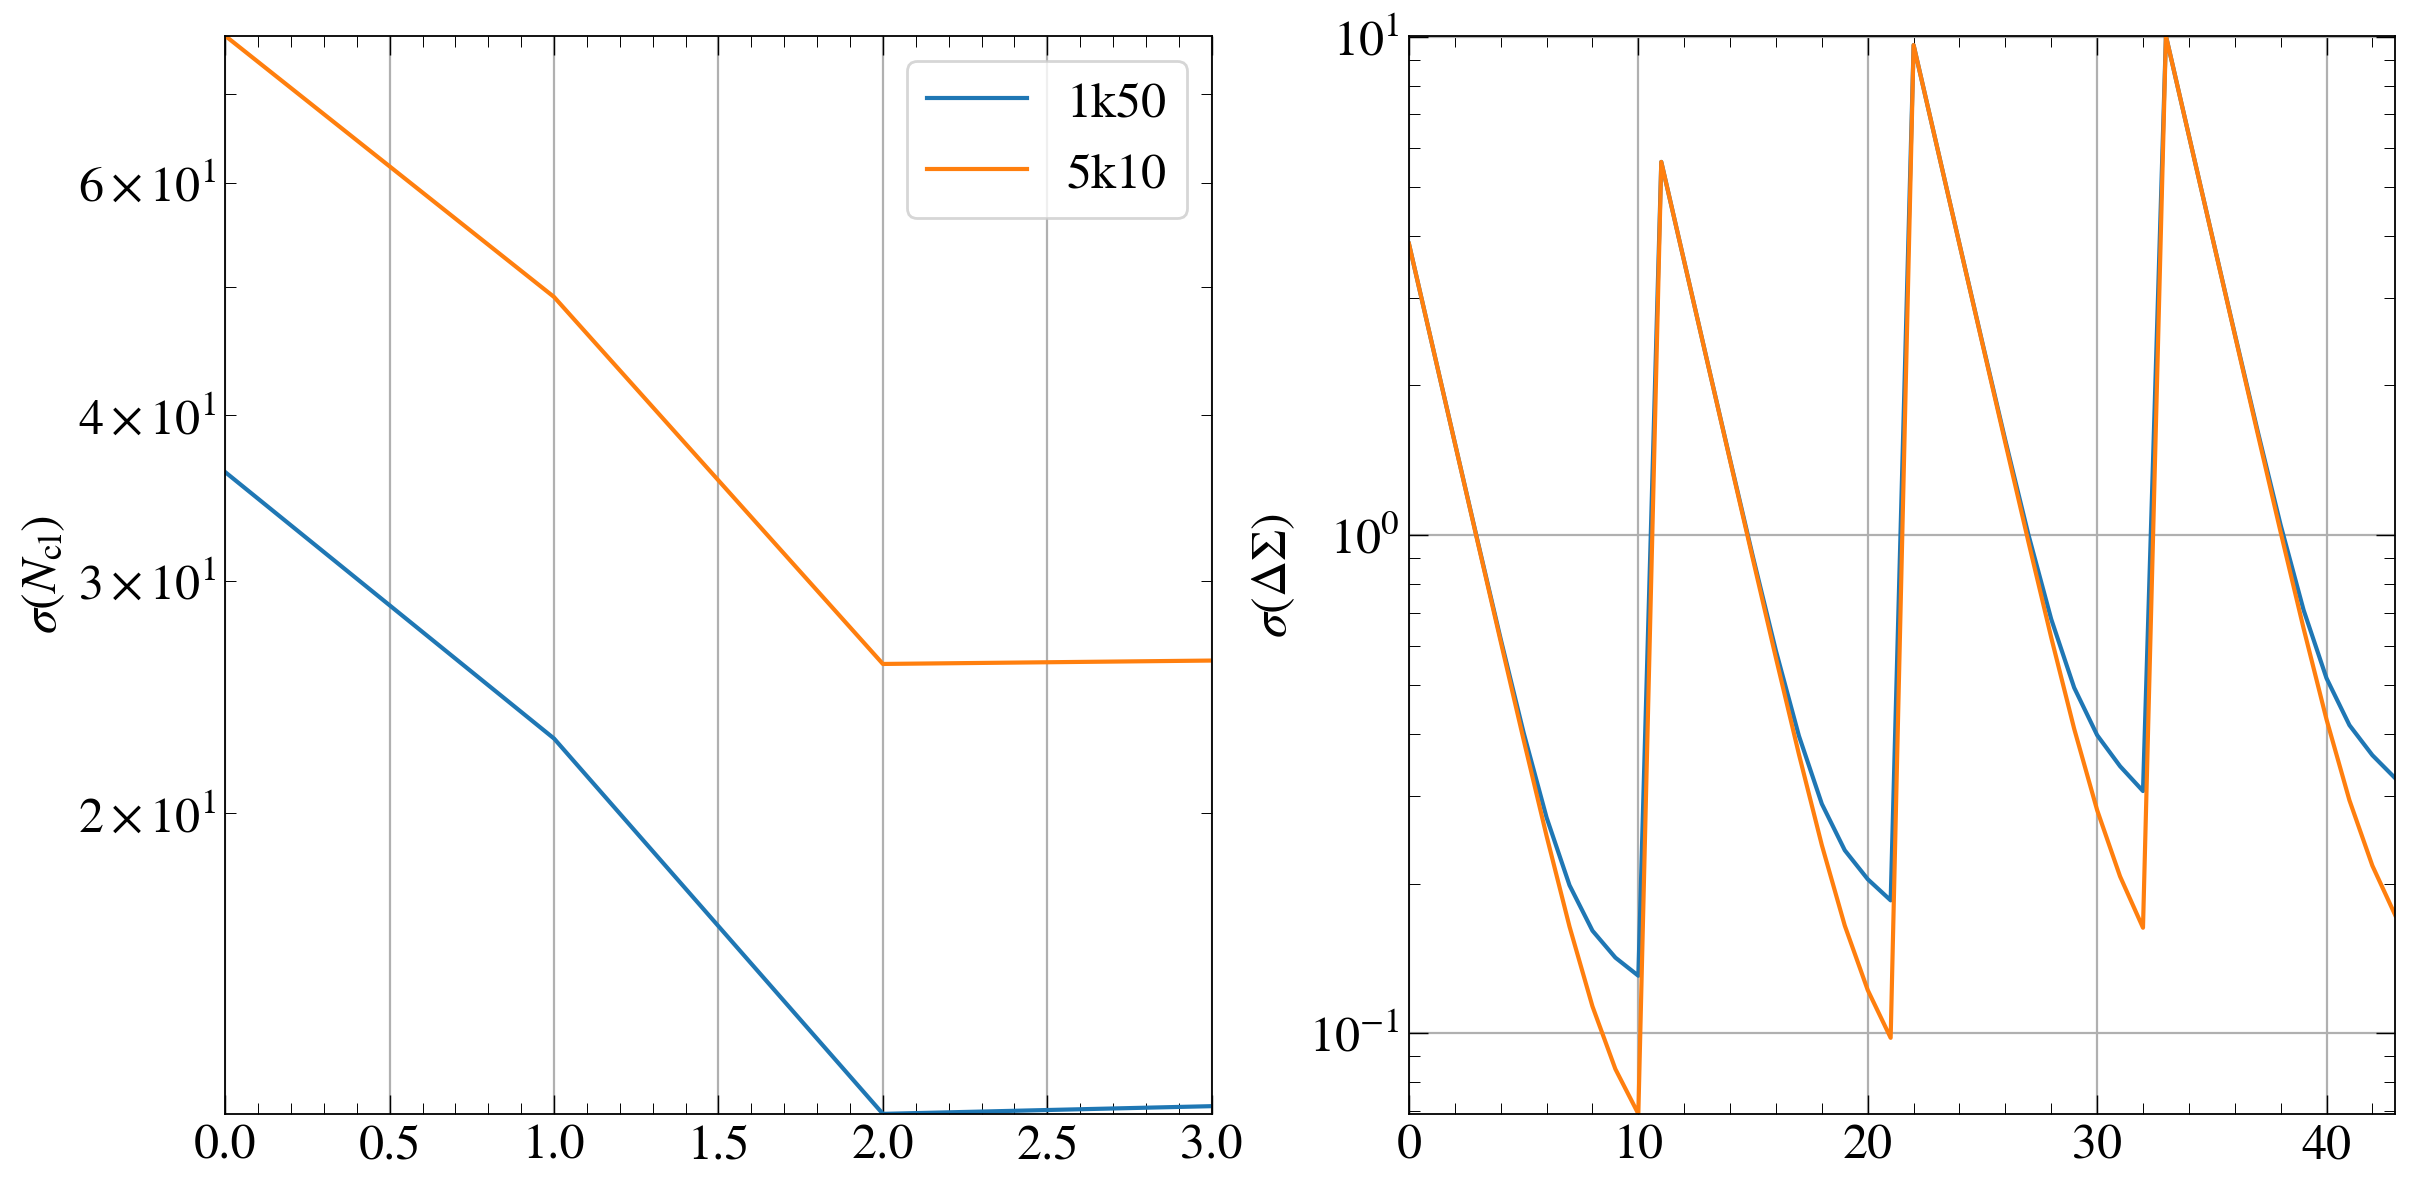

In [5]:
plt.figure(figsize=(14,7))
for cov_name in ['1k50', '5k10']:#['5k30'', '15k10, '15k30']:#, 'desy1thre']: #, 'area10k', 'nsrc50'
    
    # counts
    data = np.loadtxt(f'cov/cov_counts_{cov_name}_z{redshift}.dat')
    sig_NC = np.sqrt(np.diag(data))
    plt.subplot(121)
    plt.plot(sig_NC, label=cov_name)
    plt.ylabel(r'$\sigma(N_{\rm cl})$')
    plt.legend()
    plt.yscale('log')
    
    # lensing
    data = np.loadtxt(f'cov/cov_lensing_{cov_name}_z{redshift}.dat')
    sig_DS = np.sqrt(np.diag(data))
    plt.subplot(122)
    plt.plot(sig_DS, label=cov_name)
    plt.ylabel(r'$\sigma(\Delta\Sigma)$')
    plt.yscale('log')